In [2]:
%load_ext autoreload
%autoreload 2
import sys 
sys.path.append("../lib")

import re
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

from SIDM_density_fluid import find_closest_tr_file
from SIDM_Parametric_Model_jax import SIDM_parametric_simple

# Density

0
Input tr0: 0.0
Closest found tr: 0.0
Corresponding file: data_tr_0.00.pickle
36
Input tr0: 0.18
Closest found tr: 0.18062496953600002
Corresponding file: data_tr_0.18062496953600002.pickle
71
Input tr0: 0.35
Closest found tr: 0.35090454608
Corresponding file: data_tr_0.35090454608.pickle
102
Input tr0: 0.5
Closest found tr: 0.5002137314239999
Corresponding file: data_tr_0.5002137314239999.pickle
214
Input tr0: 1.05
Closest found tr: 1.0510360069440001
Corresponding file: data_tr_1.0510360069440001.pickle
220
Input tr0: 1.08
Closest found tr: 1.0803945546240001
Corresponding file: data_tr_1.0803945546240001.pickle


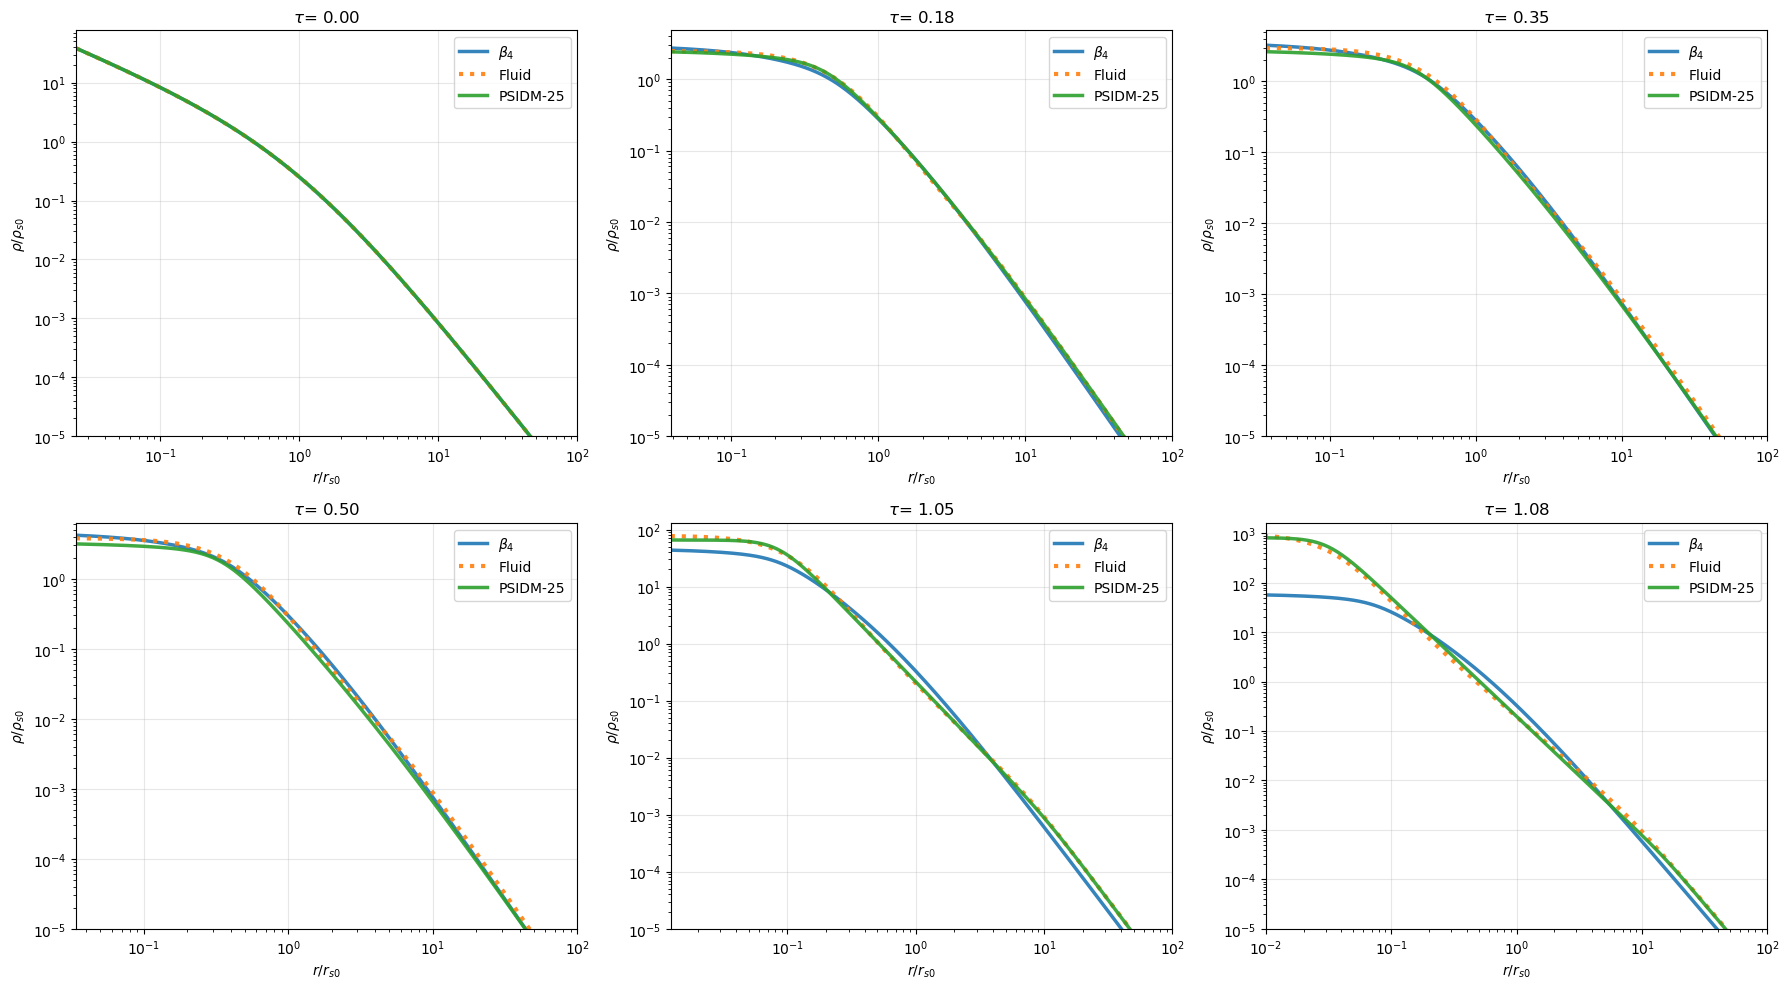

In [4]:
# Create an instance of the SIDM_parametric_simple class
sidm = SIDM_parametric_simple()

# Define the possible values for current_tr
current_tr_values = [0.0, 0.18, 0.35, 0.5, 1.05, 1.08]
tc0 = 28.7418

# Create a figure and subplots (2 rows and 3 columns)
fig, ax = plt.subplots(2, 3, figsize=(18, 10))  # Create a 2x3 grid of subplots

# Iterate over the values of current_tr and plot each subplot
for i, current_tr in enumerate(current_tr_values):
    # Calculate XXX based on current_tr and tc0
    XXX = int(current_tr * 7.1 * tc0)
    print(XXX)
    # Format the calculated value as a 3-digit string
    formatted_XXX = str(XXX).zfill(3)
    # Calculate the position of the current subplot (row, column)
    row, col = divmod(i, 3)

    # Define the data folder
    data_folder = "../lib/Processed_data"
    
    # Fluid: Automatically choose the closest file based on current_tr value
    file_path, tr = find_closest_tr_file(current_tr, data_folder)
    
    # Load the data from the selected file
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
        
    # Extract the raw data (don't apply logarithm)
    r_hy = data['r']
    rho_hy = data['rho']

    # Model: Calculate the density using the SIDM model
    density = sidm.get_density(r_hy, current_tr=tr, rhoss=1, rss=1)  # Calculate density
    density_beta4 = sidm.get_density_beta4(r_hy, current_tr=tr, rhoss=1, rss=1)  # Calculate density for beta4

    # Plot the data for the current subplot
    alphathis = 0.9  # Transparency value
    
    # Plot the density model for beta4
    ax[row, col].plot(r_hy, density_beta4, '-', linewidth=2.5, label='$\\beta_4$', alpha=alphathis)
    # Plot the fluid data
    ax[row, col].plot(r_hy, rho_hy, ':', linewidth=3, label='Fluid', alpha=alphathis)
    # Plot the SIDM model density
    ax[row, col].plot(r_hy, density, '-', linewidth=2.5, label='PSIDM-25', alpha=alphathis)
    
    # Set logarithmic scale for both x and y axes
    ax[row, col].set_xscale('log')
    ax[row, col].set_yscale('log')
    
    # Set axis labels and title for the current subplot
    ax[row, col].set_xlabel('$r/r_{s0}$')
    ax[row, col].set_ylabel('$\\rho/ \\rho_{s0}$')
    ax[row, col].set_title(f'$\\tau$= {current_tr:.2f}')
    
    # Add gridlines with low transparency
    ax[row, col].grid(alpha=0.3)
    
    # Display the legend
    ax[row, col].legend()
    
    # Set the x-axis limit (if r_hy's min value is greater than 0.01, use it; otherwise, set 0.01)
    min_val = max(0.01, r_hy.min())
    # Set x and y axis limits
    ax[row, col].set_xlim(min_val, r_hy.max())  # Ensure the x-axis shows the full range of data
    ax[row, col].set_ylim(1e-5, density.max() * 2)  # Ensure the y-axis shows a reasonable range

# Adjust the layout of the subplots to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

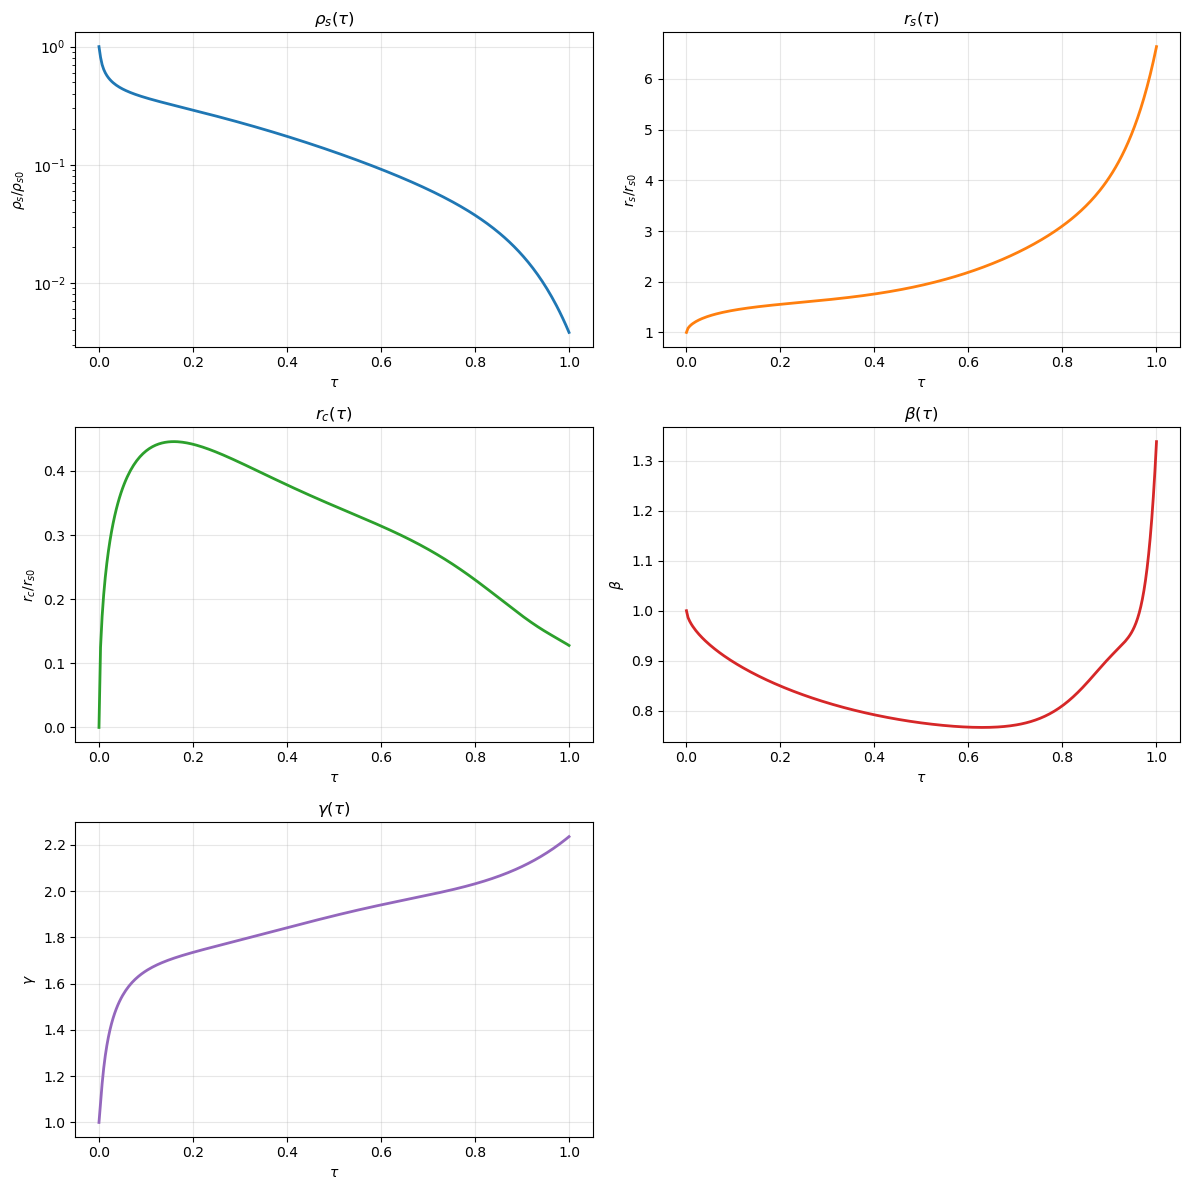

In [ ]:
# parameters

def plot_sidm_parameter_evolution(sidm=None, tr_min=0.0, tr_max=1.0, npts=300, savepath=None):
    import numpy as np
    import matplotlib.pyplot as plt

    if sidm is None:
        sidm = SIDM_parametric_simple()


    tau = np.linspace(tr_min, tr_max, npts)

    rhos_vals  = sidm.fitted_rhos(tau)
    rs_vals    = sidm.fitted_rs(tau)
    rc_vals    = sidm.fitted_rc(tau)
    beta_vals  = sidm.fitted_beta(tau)
    gamma_vals = sidm.fitted_gamma(tau)


    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    ax = axes.ravel()

    # rhos
    ax[0].plot(tau, rhos_vals, color='tab:blue', lw=2)
    ax[0].set_xlabel(r'$\tau$')
    ax[0].set_ylabel(r'$\rho_s/\rho_{s0}$')
    ax[0].set_yscale('log')
    ax[0].grid(alpha=0.3)
    ax[0].set_title(r'$\rho_s(\tau)$')

    # rs
    ax[1].plot(tau, rs_vals, color='tab:orange', lw=2)
    ax[1].set_xlabel(r'$\tau$')
    ax[1].set_ylabel(r'$r_s/r_{s0}$')
    ax[1].grid(alpha=0.3)
    ax[1].set_title(r'$r_s(\tau)$')

    # rc
    ax[2].plot(tau, rc_vals, color='tab:green', lw=2)
    ax[2].set_xlabel(r'$\tau$')
    ax[2].set_ylabel(r'$r_c/r_{s0}$')
    ax[2].grid(alpha=0.3)
    ax[2].set_title(r'$r_c(\tau)$')

    # beta 
    ax[3].plot(tau, beta_vals, color='tab:red', lw=2)
    ax[3].set_xlabel(r'$\tau$')
    ax[3].set_ylabel(r'$\beta$')
    ax[3].grid(alpha=0.3)
    ax[3].set_title(r'$\beta(\tau)$')

    # gamma
    ax[4].plot(tau, gamma_vals, color='tab:purple', lw=2)
    ax[4].set_xlabel(r'$\tau$')
    ax[4].set_ylabel(r'$\gamma$')
    ax[4].grid(alpha=0.3)
    ax[4].set_title(r'$\gamma(\tau)$')

    ax[5].axis('off')

    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath, dpi=200, bbox_inches='tight')
    else:
        plt.show()

plot_sidm_parameter_evolution()

# Lensing

In [7]:
import numpy as np
import scipy
from scipy.interpolate import interp1d
from scipy.integrate import quad_vec
import matplotlib.pyplot as plt
import pickle
import os
import re


def find_closest_tr_file(tr0, folder):
    tr_values = []
    filenames = []
    # Regular expression to match tr values
    tr_pattern = re.compile(r"data_tr_(\d+\.\d+)\.pickle")  
    
    # Traverse the folder to find matching files
    for file in os.listdir(folder):
        match = tr_pattern.match(file)
        if match:
            tr = float(match.group(1))
            tr_values.append(tr)
            filenames.append(file)
    
    if not tr_values:
        raise FileNotFoundError("No matching 'data_tr_*.pickle' files found in the specified folder.")
    
    # Find the closest tr
    tr_values = np.array(tr_values)
    closest_idx = np.argmin(np.abs(tr_values - tr0))
    closest_file = filenames[closest_idx]
    closest_tr = tr_values[closest_idx]
    
    print(f"Input tr0: {tr0}")
    print(f"Closest found tr: {closest_tr}")
    print(f"Corresponding file: {closest_file}")
    
    return os.path.join(folder, closest_file), closest_tr

rvir = 2000

# Define vectorized density function
def frhoRZ(R, z, rho_interp):
    rx = np.sqrt(R**2 + z**2)
    return np.where(rx < rvir, rho_interp(rx), 0)

# Vectorized integration function
def integrate_density_along_Z_vectorized(pos, rho_inter):
    def fint(z, R):
        return frhoRZ(R, z, rho_inter)
    
    # Use scipy.integrate.quad_vec for vectorized integration
    result, _ = quad_vec(
        lambda z, R: fint(z, R),  # Integration function
        -rvir, rvir,             # Integration range
        args=(pos,),             # Pass position array
        points=[0],              # Provide possible integration feature points (e.g., z=0)
        epsabs=1e-4, epsrel=1e-4 # Adjust precision
    )
    return result

# Vectorized integration to calculate hPsi
def integrate_hPsi_vectorized(pos, flnSigma):
    def fint(s, R):
        return 2 * s * np.exp(flnSigma(np.log(s))) * np.log(R / s)
    
    result = []
    for R in pos:
        val, _ = scipy.integrate.quad(
            lambda s: fint(s, R),
            1e-5, R,  # Integrate from a small non-zero value to pos
            epsabs=1e-4, epsrel=1e-4
        )
        result.append(val)
    return np.array(result)

def fited_a(x):
    a, b, c, d, g, h, i, j, k = 1.11323951e+00, -1.26183924e+00,  2.87611831e+00, -3.61577534e+00,2.77768241e+00, -4.15935892e-01,  1.35746091e-02, -3.86240111e-02,-2.63332737e-04
    return a + b*x**0.1 + c*x**0.2 + d*x**0.5 + g*x**0.9+h*x**2+i*x**12+j*x**20+k*x**87

def fited_b(x):
    a, b, c, d, g, h, i, j,k,l = 6.59669818e+00,  2.21289181e+00, -9.56284544e+00,  9.10385757e+00, -4.01289646e+00,  3.26789716e+00,  2.07641520e+00,  1.18377949e-01, -2.10519668e-04,  4.21396052e-07
    return a + b*x**0.01 + c*x**0.2 + d*x**0.6 + g*x**0.9+h*x**2+i*x**12+j*x**51+k*x**109+l*x**203

def fited_c(x):
    a, b, c, d, g, h, i, j = 1.79309631e+00,  5.10780441e-01, -1.43007683e+00,  1.39244251e+00, -7.85787233e-01,  1.60384916e-01,  3.14558126e-02,  7.14758319e-04
    return a + b*x**0.1 + c*x**0.2 + d*x**0.4 + g*x**0.9+h*x**2+i*x**12+j*x**67

def fited_p(x):
    a, b, c, d, g, h, i, j = 6.94266549, 4.96669252, -12.52779021, 7.54562512, 3.21238241, 2.86297753, -0.32646638, 0.30926922
    return a + b*x**0.2 + c*x**0.3 + d*x**0.8 + g*x**2+h*x**11+i*x**22+j*x**37

def fited_s(x):
    a, b, c, d, g, h, i, j = 1.82544721e+00, -5.99111491e-01, 8.44850940e-01, -4.34593883e-01, 8.17550753e-02, 1.67462383e-02, -1.75109111e-03, 3.82847738e-03
    return a + b*x**0.2 + c*x**0.3 + d*x**0.8 + g*x**2+h*x**11+i*x**22+j*x**37

def func_potential(logr, a, b, c, d, e):
    r = np.exp(logr)
    result = a*np.log(1+b*r+c*r**2)**c-np.log(d*r+1)**e
    return np.log(result)

def func_alpha(logr, a, b, c, d, e):

    r = np.exp(logr)  # Convert r from log scale to actual scale

    # Calculate the first fraction term
    term1 = (a * c * (b + 2 * c * r) * np.log(b * r + c * r**2 + 1)**(c - 1)) / (b * r + c * r**2 + 1)
    
    # Calculate the second fraction term
    term2 = (d * e * np.log(d * r + 1)**(e - 1)) / (d * r + 1)
    
    # Subtract the two terms
    derivative = term1 - term2
    
    return np.log(derivative)  # Take the natural log of the result

def kappa(logr, a, b, c, d, e):
    r = np.exp(logr)  # Convert r from log scale to actual scale
    
    # First group of terms inside the braces
    term1 = (2 * a * c**2 * np.log(b * r + c * r**2 + 1)**(c - 1)) / (b * r + c * r**2 + 1)
    term2 = (a * (c - 1) * c * (b + 2 * c * r)**2 * np.log(b * r + c * r**2 + 1)**(c - 2)) / (b * r + c * r**2 + 1)**2
    term3 = (a * c * (b + 2 * c * r)**2 * np.log(b * r + c * r**2 + 1)**(c - 1)) / (b * r + c * r**2 + 1)**2
    term4 = (d**2 * e * np.log(d * r + 1)**(e - 1)) / (d * r + 1)**2
    term5 = (d**2 * (e - 1) * e * np.log(d * r + 1)**(e - 2)) / (d * r + 1)**2
    
    # Second group of two separate terms
    term6 = (a * c * (b + 2 * c * r) * np.log(b * r + c * r**2 + 1)**(c - 1)) / (b * r + c * r**2 + 1)
    term7 = (d * e * np.log(d * r + 1)**(e - 1)) / (d * r + 1)
    
    # Combine all terms
    numerator = r * (term1 + term2 - term3 + term4 - term5) + term6 - term7
    
    # Denominator is 2 * r
    derivative = numerator / (2 * r)
    
    return np.log(derivative)  # Take the natural log of the result

Input tr0: 0.001
Closest found tr: 0.001
Corresponding file: data_tr_0.001.pickle
Input tr0: 0.15
Closest found tr: 0.14902958012800002
Corresponding file: data_tr_0.14902958012800002.pickle
Input tr0: 0.8
Closest found tr: 0.8007893386240001
Corresponding file: data_tr_0.8007893386240001.pickle
Input tr0: 1.05
Closest found tr: 1.0510360069440001
Corresponding file: data_tr_1.0510360069440001.pickle
Input tr0: 0.001
Closest found tr: 0.001
Corresponding file: data_tr_0.001.pickle
Input tr0: 0.15
Closest found tr: 0.14902958012800002
Corresponding file: data_tr_0.14902958012800002.pickle
Input tr0: 0.8
Closest found tr: 0.8007893386240001
Corresponding file: data_tr_0.8007893386240001.pickle
Input tr0: 1.05
Closest found tr: 1.0510360069440001
Corresponding file: data_tr_1.0510360069440001.pickle


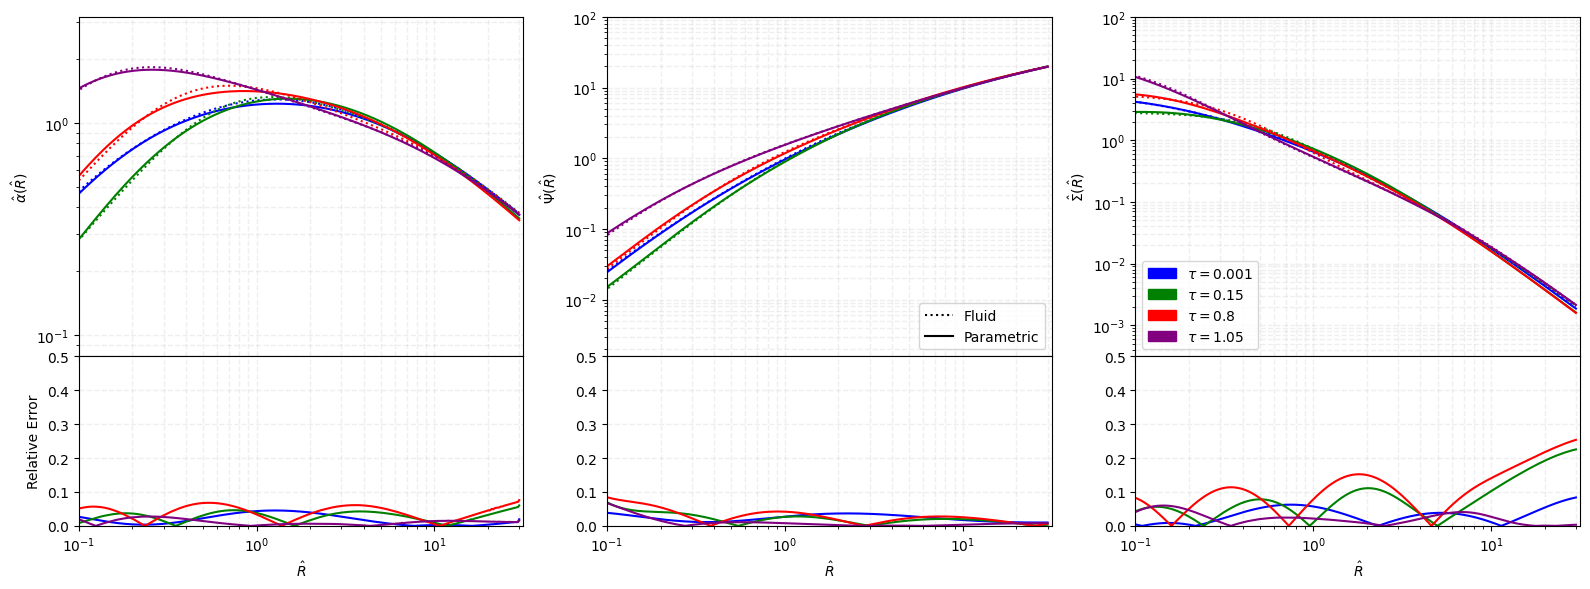

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import pickle
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# User-provided 4 τ values
taus = [0.001, 0.15, 0.80, 1.05]  # Example input, can be modified to any 4 τ values

# Specify the folder path
data_folder = "../lib/Processed_data"

# Automatically select the closest files
file_paths = [find_closest_tr_file(tau, data_folder)[0] for tau in taus]
tr = [find_closest_tr_file(tau, data_folder)[1] for tau in taus]

# Preserved colors0
colors0 = ['blue', 'green', 'red', 'purple']

# Create canvas and grid layout
fig, axes = plt.subplots(2, 3, figsize=(16, 6), gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})

for i, (tau, file_path, color) in enumerate(zip(taus, file_paths, colors0)):
    # Load data
    with open(file_path, 'rb') as f:
        data = pickle.load(f)

    # Extract original data (do not take logarithm)
    r = data['r']
    rho = data['rho']
    tr0 = tr[i]

    # Calculate projected density
    pos = np.logspace(np.log10(r.min()), np.log10(0.3 * r.max()), 500)  # Position
    rho_inter_this = interp1d(r, rho, bounds_error=False, fill_value=0)
    sigma_R = integrate_density_along_Z_vectorized(pos, rho_inter_this)

    flnSigma_this = interp1d(np.log(pos), np.log(sigma_R), kind='linear', fill_value="extrapolate")
    hPsi = integrate_hPsi_vectorized(pos, flnSigma_this)

    alpha = np.gradient(hPsi, pos)
    a = fited_a(tr0)
    b = fited_b(tr0)
    c = fited_c(tr0)
    d = fited_p(tr0)
    s = fited_s(tr0)

    y_fit_alpha = np.exp(func_alpha(np.log(pos), a, b, c, d, s))
    y_fit_potential = np.exp(func_potential(np.log(pos), a, b, c, d, s))
    y_fit_kappa = np.exp(kappa(np.log(pos), a, b, c, d, s))

    # Calculate relative error
    relative_error_sigma = np.abs(sigma_R - y_fit_kappa) / np.abs(sigma_R)
    relative_error_hPsi = np.abs(hPsi - y_fit_potential) / np.abs(hPsi)
    relative_error_alpha = np.abs(alpha - y_fit_alpha) / np.abs(alpha)

    # Plot first row - main plots
    # Alpha (log-log scale)
    axes[0, 0].loglog(pos, alpha, color=color, linestyle=':')  # True value
    axes[0, 0].loglog(pos, y_fit_alpha, linestyle='-', color=color)
    # Potential (log-log scale)
    axes[0, 1].loglog(pos, hPsi, color=color, linestyle=':')  # True value
    axes[0, 1].loglog(pos, y_fit_potential, linestyle='-', color=color)
    # Sigma (log-log scale)
    axes[0, 2].loglog(pos, sigma_R, color=color, linestyle=':')  # True value
    axes[0, 2].loglog(pos, y_fit_kappa, linestyle='-', color=color)

    # Plot second row - error plots
    # Alpha error
    axes[1, 0].semilogx(pos, relative_error_alpha, color=color)
    # Potential error
    axes[1, 1].semilogx(pos, relative_error_hPsi, color=color)
    # Sigma error
    axes[1, 2].semilogx(pos, relative_error_sigma, color=color)

# Set axis labels
# First row
axes[0, 0].set_ylabel(r'$\hat{\alpha}(\hat{R})$')
axes[0, 1].set_ylabel(r'$\hat{\Psi}(\hat{R})$')
axes[0, 2].set_ylabel(r'$\hat{\Sigma}(\hat{R})$')
axes[0, 0].tick_params(labelbottom=False)
axes[0, 1].tick_params(labelbottom=False)
axes[0, 2].tick_params(labelbottom=False)

# Second row
axes[1, 0].set_xlabel(r'$\hat{R}$')
axes[1, 0].set_ylabel(r'Relative Error')
axes[1, 1].set_xlabel(r'$\hat{R}$')
axes[1, 2].set_xlabel(r'$\hat{R}$')

# Set x-axis range to [10^-1, 10^1.5]
for ax in axes.flatten():
    ax.set_xlim([10**-1, 10**1.5])
    ax.grid(True, which='both', linestyle='--', linewidth=1, alpha=0.2)

# Set y-axis range for error plots to [0, 0.5]
for ax in axes[1]:
    ax.set_ylim([0, 0.5])

axes[0, 0].set_ylim([10**-1.1, 10**0.5])
axes[0, 1].set_ylim([10**-2.8, 10**2])
axes[0, 2].set_ylim([10**-3.5, 10**2])

# Set color patches and legend
# Create color patches
patches = [Patch(color=color, label=f'$\\tau={tau}$') for tau, color in zip(taus, colors0)]

# Create additional legend entries (for Dash and Solid descriptions)
dash_patch = Line2D([0], [0], color='black', linestyle=':', label='Fluid')  # Dash
solid_patch = Line2D([0], [0], color='black', linestyle='-', label='Parametric')  # Solid

# Add both color patches and Dash/Solid descriptions to the legend
axes[0, 2].legend(handles=patches, loc='lower left', bbox_to_anchor=(0, 0))
axes[0, 1].legend(handles=[dash_patch, solid_patch], loc='lower right', bbox_to_anchor=(1, 0))

plt.tight_layout()
plt.show()